# Import Libraries

In [17]:
import pandas as pd
import requests
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import numpy as np

## Web Services (APIs)
- fetching data.
- Converting to DataFrames

In [13]:
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"

url = f"{base_url}/api/3/action/package_show"
params = {"id": "marriage-licence-statistics"}

headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, params=params, headers=headers)
response.raise_for_status()
package_data = response.json()

resources = package_data["result"]["resources"]
datastore_resource = next(
    (res for res in resources if res.get("datastore_active")), None
)

if not datastore_resource:
    datastore_resource = resources[0]

resource_id = datastore_resource["id"]

datastore_url = f"{base_url}/api/3/action/datastore_search"
data_response = requests.get(
    datastore_url,
    params={"resource_id": resource_id, "limit": 100},
    headers=headers,
)
data_response.raise_for_status()

records = data_response.json()["result"]["records"]
df = pd.DataFrame(records)

print("--- Toronto Marriage Statistics Sample ---")
print(df.head())
  

--- Toronto Marriage Statistics Sample ---
     _id CIVIC_CENTRE  MARRIAGE_LICENSES TIME_PERIOD
0  27811           ET                 80     2011-01
1  27812           NY                136     2011-01
2  27813           SC                159     2011-01
3  27814           TO                367     2011-01
4  27815           ET                109     2011-02


## Relational Databases
- portable setup without setting up PostgreSQL.
- SQLAlchemy supports SQLite seamlessly

In [14]:
engine = create_engine("sqlite:///:memory:")

df_csv = pd.read_csv("./data/california_housing_data.csv")
df_csv.to_sql("california_housing", engine, index=False, if_exists="replace")

filter_query = text("""
    SELECT MedInc, HouseAge, AveRooms, Population, MedHouseVal
    FROM california_housing
    WHERE MedInc > :min_income AND MedHouseVal >= :min_val
    ORDER BY MedHouseVal DESC, MedInc DESC
""")

with engine.connect() as conn:
    df_filtered = pd.read_sql(
        filter_query, conn, params={"min_income": 6.0, "min_val": 4.0}
    )

print("--- Top High-Income / High-Value Neighborhoods ---")
print(df_filtered.head())

agg_query = text("""
    SELECT 
        CASE 
            WHEN HouseAge < 15 THEN 'New (<15 yrs)'
            WHEN HouseAge BETWEEN 15 AND 35 THEN 'Mid-age (15-35 yrs)'
            ELSE 'Old (>35 yrs)'
        END AS age_group,
        COUNT(*) AS block_count,
        ROUND(AVG(MedInc), 2) AS avg_income,
        ROUND(AVG(MedHouseVal), 2) AS avg_house_val
    FROM california_housing
    GROUP BY age_group
    ORDER BY avg_house_val DESC
""")

with engine.connect() as conn:
    df_aggregated = pd.read_sql(agg_query, conn)

print("\n--- Housing Summary by Building Age ---")
print(df_aggregated)

--- Top High-Income / High-Value Neighborhoods ---
    MedInc  HouseAge  AveRooms  Population  MedHouseVal
0  15.0001      37.0  8.659574       100.0      5.00001
1  15.0001      52.0  8.444954       693.0      5.00001
2  15.0001      52.0  8.483019       813.0      5.00001
3  15.0001      52.0  9.204969       531.0      5.00001
4  15.0001      52.0  7.958333       457.0      5.00001

--- Housing Summary by Building Age ---
             age_group  block_count  avg_income  avg_house_val
0        Old (>35 yrs)         6344        3.61           2.20
1  Mid-age (15-35 yrs)        11521        3.90           2.03
2        New (<15 yrs)         2775        4.34           1.94


## Problem Definition Prediction: 
- Median Income (MedInc) in $10,000s.Target 
- Median House Value (MedHouseVal) in $100,000s.
- Objective: Predict house values using a single predictor via simple linear regression. 
- MedInc is selected because it represents the strongest linear correlation ($r \approx 0.69$) with median house values in the California Housing dataset.

## Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Dataset
df = pd.read_csv("./data/california_housing_data.csv")

# Feature Matrix (X) and Target Vector (y)
X = df[["MedInc"]]
y = df["MedHouseVal"]

# 2. Handle Missing Data
# Checking for null values
missing_data = X.isnull().sum()
print("Missing values in MedInc:", missing_data.sum())

# If missing values were present, we would impute them:
# X['MedInc'] = X['MedInc'].fillna(X['MedInc'].median())

# 3. Train / Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

# Fit ONLY on training data to prevent data leakage, then transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Missing values in MedInc: 0


# Modeling:

- Mathematical Foundations:

    - Hypothesis:
    - MSE Cost Function:
    - Gradient Descent Updates:

--- Training Mathematical Model ---
Epoch    0 | Cost J(θ): 6.204971 | θ_0: 0.3410 | θ_1: 0.1864
Epoch  200 | Cost J(θ): 0.007322 | θ_0: 2.2001 | θ_1: 2.6028
Epoch  400 | Cost J(θ): 0.001377 | θ_0: 2.0565 | θ_1: 2.8866
Epoch  600 | Cost J(θ): 0.001030 | θ_0: 2.0218 | θ_1: 2.9552
Epoch  800 | Cost J(θ): 0.001009 | θ_0: 2.0134 | θ_1: 2.9717

--- Final Converged Model Parameters ---
Intercept (θ_0): 2.0114  (Target: ~2.0000)
Slope     (θ_1): 2.9757  (Target: ~3.0000)
Final Cost J(θ): 0.001008


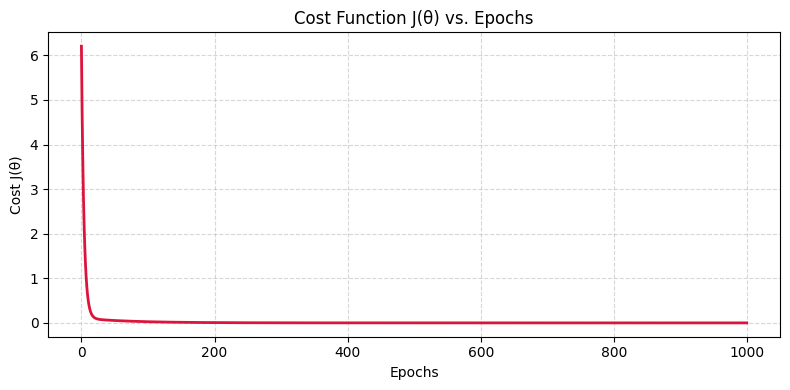

In [ ]:
# 1. GENERATE SYNTHETIC DATASET

np.random.seed(42)

# Relationship: y = 2.0 + 3.0 * x + noise
x = np.random.rand(100)
y = 2.0 + 3.0 * x + np.random.randn(100) * 0.05
m = len(y)

# 2. HYPERPARAMETERS & INITIALIZATION

lr = 0.1
epochs = 1000

theta_0 = 0.0  # Initial intercept / bias
theta_1 = 0.0  # Initial slope / weight
cost_history = []

print("--- Training Mathematical Model ---")


# 3. GRADIENT DESCENT LOOP (DIRECT LINE-BY-LINE EXECUTION)

for epoch in range(epochs):

    # 1. Compute Hypothesis / Predictions: h_θ(x) = θ_0 + θ_1 * x
    predictions = theta_0 + theta_1 * x

    # 2. Compute Mean Squared Error (MSE) Cost J(θ)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    cost_history.append(cost)

    # 3. Compute Gradients (Partial Derivatives)
    error = predictions - y
    d_theta_0 = (1 / m) * np.sum(error)
    d_theta_1 = (1 / m) * np.sum(error * x)

    # 4. Simultaneously Update Model Parameters
    theta_0 -= lr * d_theta_0
    theta_1 -= lr * d_theta_1

    # Print output every 200 epochs
    if epoch % 200 == 0:
        print(
            f"Epoch {epoch:4d} | Cost J(θ): {cost:.6f} | θ_0: {theta_0:.4f} | θ_1: {theta_1:.4f}"
        )

# 4. FINAL CONVERGED PARAMETERS & OUTPUT

final_predictions = theta_0 + theta_1 * x
final_cost = (1 / (2 * m)) * np.sum((final_predictions - y) ** 2)

print("\n--- Final Converged Model Parameters ---")
print(f"Intercept (θ_0): {theta_0:.4f}  (Target: ~2.0000)")
print(f"Slope     (θ_1): {theta_1:.4f}  (Target: ~3.0000)")
print(f"Final Cost J(θ): {final_cost:.6f}")

# 5. VISUALIZE COST CONVERGENCE

plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="crimson", linewidth=2)
plt.title("Cost Function J(θ) vs. Epochs", fontsize=12)
plt.xlabel("Epochs", fontsize=10)
plt.ylabel("Cost J(θ)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Implementation & Comparison

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# FIX: Load and preprocess data so X_train_scaled, y_train, etc. exist
df = pd.read_csv("./data/california_housing_data.csv")
X = df[["MedInc"]].values
y = df["MedHouseVal"].values

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- A. Custom Implementation From Scratch ---
class LinearRegressionGD:

    def __init__(self, lr=0.05, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.theta_0 = 0.0
        self.theta_1 = 0.0

    def fit(self, X, y):
        m = len(y)
        X_flat = X.flatten()

        for _ in range(self.epochs):
            predictions = self.theta_0 + self.theta_1 * X_flat
            d_theta_0 = (1 / m) * np.sum(predictions - y)
            d_theta_1 = (1 / m) * np.sum((predictions - y) * X_flat)

            self.theta_0 -= self.lr * d_theta_0
            self.theta_1 -= self.lr * d_theta_1

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X.flatten()


scratch_model = LinearRegressionGD(lr=0.05, epochs=1000)
scratch_model.fit(X_train_scaled, y_train)
y_pred_scratch = scratch_model.predict(X_test_scaled)

# --- B. Scikit-Learn Model ---
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled, y_train)
y_pred_sklearn = sklearn_model.predict(X_test_scaled)

# Print results to verify correct execution
print("Scratch MSE:", mean_squared_error(y_test, y_pred_scratch))
print("Sklearn MSE:", mean_squared_error(y_test, y_pred_sklearn))

Scratch MSE: 0.7091157771765549
Sklearn MSE: 0.7091157771765548


# Evaluation
- performing the evaluation step (calculating RMSE, MAE, and $R^2$). 
- plotting the fitted regression line against actual test dataset.

Matplotlib is building the font cache; this may take a moment.


RMSE : 0.8421
MAE  : 0.6299
R²   : 0.4589


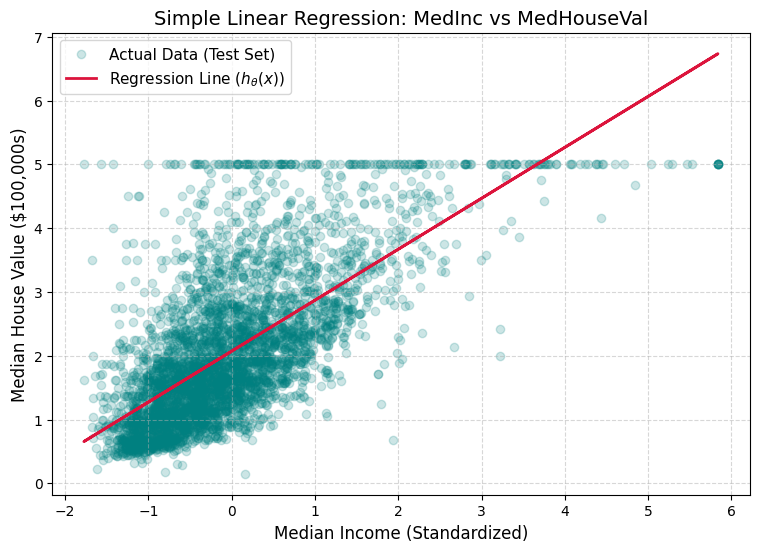

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load & Split Data
df = pd.read_csv('./data/california_housing_data.csv')
X = df[['MedInc']].values
y = df['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale & Train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 3. Predict & Evaluate
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

# 4. Plot Regression Line vs Actual Data
plt.figure(figsize=(9, 6))
plt.scatter(X_test_scaled, y_test, color='teal', alpha=0.2, label='Actual Data (Test Set)')
plt.plot(X_test_scaled, y_pred, color='crimson', linewidth=2, label=r'Regression Line ($h_\theta(x)$)')
plt.title('Simple Linear Regression: MedInc vs MedHouseVal', fontsize=14)
plt.xlabel('Median Income (Standardized)', fontsize=12)
plt.ylabel('Median House Value ($100,000s)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()